# Black Bar Removal & Resize

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import shutil
from pathlib import Path

In [6]:
INPUT_DIR  = Path("./data_images/MIQR-CC-Dataset/processed")

In [7]:
EXTENSIONS = {".png"}
TARGET     = (512, 512)
THRESHOLD  = 10   # rows with mean intensity below this are considered black


def crop_black_bars(img):
    gray      = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    row_means = gray.mean(axis=1)
    top       = next((i for i, v in enumerate(row_means)            if v > THRESHOLD), 0)
    bottom    = next((i for i, v in enumerate(reversed(row_means))  if v > THRESHOLD), 0)
    return img[top : len(row_means) - bottom]


def process(path):
    img     = cv2.imread(str(path))
    cropped = crop_black_bars(img)
    resized = cv2.resize(cropped, TARGET, interpolation=cv2.INTER_LANCZOS4)
    cv2.imwrite(str(path), resized)


def is_outlier(path):
    img  = cv2.imread(str(path))
    h, w = img.shape[:2]
    return w != TARGET[0] or h != TARGET[1]

In [8]:
images   = [p for p in INPUT_DIR.rglob("*") if p.suffix.lower() in EXTENSIONS]
outliers = [p for p in images if is_outlier(p)]

print(f"Total images : {len(images)}")
print(f"Outliers     : {len(outliers)}")

Total images : 19318
Outliers     : 496


In [11]:
for path in outliers:
    process(path)

print(f"Done. Output in: {INPUT_DIR.resolve()}")

Done. Output in: C:\Users\LEGION\Desktop\universidade\Mestrado\DAA\AP_Modulo2\training\data_images\MIQR-CC-Dataset\processed


In [ ]:
INPUT_DIR  = Path("./dataset")
OUTPUT_DIR = Path("./dataset_cleaned")
def other_process(src, dst):
    img     = cv2.imread(str(src))
    cropped = crop_black_bars(img)
    resized = cv2.resize(cropped, TARGET, interpolation=cv2.INTER_LANCZOS4)
    dst.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(dst), resized)

In [ ]:
images   = [p for p in INPUT_DIR.rglob("*") if p.suffix.lower() in EXTENSIONS]
outliers = [p for p in images if is_outlier(p)]

print(f"Total images : {len(images)}")
print(f"Outliers     : {len(outliers)}")

In [ ]:
for src in images:
    dst = OUTPUT_DIR / src.relative_to(INPUT_DIR)
    if src in outliers:
        other_process(src, dst)
    else:
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)

print(f"Done. Output in: {OUTPUT_DIR.resolve()}")

## Manual validation

In [13]:
def verify(path):
    out_path = Path(path)
    src_path = INPUT_DIR / out_path.relative_to(OUTPUT_DIR)

    src = cv2.imread(str(src_path))
    out = cv2.imread(str(out_path))

    _, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(cv2.cvtColor(src, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Original  {src.shape[1]}×{src.shape[0]}")
    axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Processed {out.shape[1]}×{out.shape[0]}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


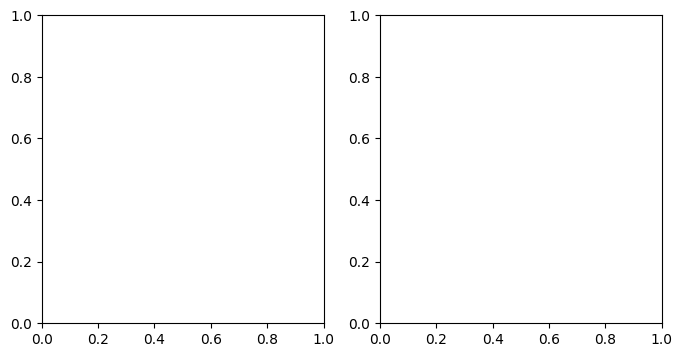

In [14]:
verify("dataset_cleaned/subfolder/image.jpg")